**Parte 0**: Connessione Google Drive a Google Colab così posso utilizzare il dataset e import delle librerie che servono

In [30]:
!pip install pgmpy
!apt-get install -y swi-prolog
!pip install pyswip
import os
import zipfile
import urllib.request
import pandas as pd
import datetime
import numpy as np
import warnings
from os import system

#librerie che servono per l'albero decisionale
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#librerie per la rete neurale
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

#librerie per la rete bayesiana
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score

#librerie per prolog
from pyswip import Prolog

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
swi-prolog is already the newest version (8.4.2+dfsg-2ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


**Parte 1**: Caricamento del dataset HomeC.cvs, pulizia di questo sistemando errori e feature engineering (ovvero creazione caratteristiche)

In [19]:
url = "https://github.com/MeliotaLucia/EnergySafe/raw/main/HomeC.zip"
zip_path = "HomeC.zip"
if not os.path.exists(zip_path):
    print("Scaricamento del dataset in corso...")
    urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")
    print("Dataset estratto correttamente!")
df = pd.read_csv('HomeC.csv')

warnings.filterwarnings("ignore", category=FutureWarning)
# Controlli generali del dataset: numero righe e colonne, visualizzazione delle righe e se ci sono valori mancanti
print(f"Il dataset ha {df.shape[0]} righe e {df.shape[1]} colonne.")
print(df.columns)
print(df.isnull().sum())

# Sistemiamo le cose da sistemare: Siccome a quanto pare c'è un'ultima riga vuota, la eliminiamo
df = df.dropna()

#Alcuni input in time sono non interi, quindi ci sono dei problemi. Convertiamo qualsiasi stringa in numero.
df['time'] = pd.to_numeric(df['time'], errors='coerce') #se non è una stringa che in realtà è un numero, diventa NaN
df = df.dropna(subset=['time']) #eliminiamo il NaN
df['time'] = df['time'].astype(int)
df['time'] = pd.to_numeric(df['time'])

# Trasformiamo il tempo nel formato corretto
df['dt_time'] = pd.to_datetime(df['time'], unit='s')
df['hour'] = df['dt_time'].dt.hour
df['month'] = df['dt_time'].dt.month
df['is_weekend'] = df['dt_time'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Creiamo una colonna "fascia_prezzo" che riguarda il risaprmio energetico, che sono tre fasce: costa meno, costa medio, costa troppo - queste fasce sono quelle reali
def assegna_fascia(row):
    ora = row['dt_time'].hour
    giorno = row['dt_time'].dayofweek # 0=Lunedì, 6=Domenica
    # Fascia F3: Domenica tutta la giornata o ogni giorno dalle 23 alle 7
    if giorno == 6 or ora >= 23 or ora < 7:
        return 'F3'
    # Fascia F2: Sabato (7-23) o feriali (7-8 e 19-23)
    if giorno == 5:
        if 7 <= ora < 23:
            return 'F2'
        else:
            return 'F3' # Sabato prima delle 7 o dopo le 23 è F3
    else: # Giorni feriali (Lunedì-Venerdì)
        if (7 <= ora < 8) or (19 <= ora < 23):
            return 'F2'
        elif 8 <= ora < 19:
            return 'F1'
        else:
            return 'F3'
# Applichiamo la funzione al dataset
df['fascia_oraria'] = df.apply(assegna_fascia, axis=1)
print(df['fascia_oraria'].value_counts()) # per vedere se ho abbastanza diversità nel dataset per le varie fasce e si: 42% dei dati in F3, il 32% in F1 e il 26% in F2
# Trasformiamo la fascia_oraria in numeri
df['fascia_num'] = df['fascia_oraria'].map({'F1': 1, 'F2': 2, 'F3': 3})

# Creiamo le 3 categorie di consumo: 0 (carico basso), 1 (carico medio), 2 (carico alto)
# Divide equamente, in base ai kW, le tre categorie di consumo
df['target_carico'] = pd.qcut(df['use [kW]'], q=3, labels=[0, 1, 2])
# Vediamo i limiti di consumo per ogni categoria
# Creiamo la tabella
tabella_intervalli = df.groupby('target_carico', observed=True)['use [kW]'].agg(['min', 'max']).reset_index()
tabella_intervalli.columns = ['Classe di Carico', 'Consumo Min (kW)', 'Consumo Max (kW)']
tabella_intervalli['Classe di Carico'] = ['0 (Basso)', '1 (Medio)', '2 (Alto)']
print("RIASSUNTO SOGLIE DI CONSUMO:")
display(tabella_intervalli)

# Media mobile del consumo, prende anche i due valori precedenti a questo per avere appunto la memoria, senza picchi a caso
df['use_MA_3'] = df['use [kW]'].rolling(window=3).mean().fillna(0) # questo prende la media delle scorse 3 volte

Scaricamento del dataset in corso...
Dataset estratto correttamente!


/tmp/ipython-input-1042623342.py:9: DtypeWarning: Columns (0,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('HomeC.csv')


Il dataset ha 503911 righe e 32 colonne.
Index(['time', 'use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]',
       'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]',
       'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]',
       'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
       'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature',
       'icon', 'humidity', 'visibility', 'summary', 'apparentTemperature',
       'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity',
       'dewPoint', 'precipProbability'],
      dtype='object')
time                   0
use [kW]               1
gen [kW]               1
House overall [kW]     1
Dishwasher [kW]        1
Furnace 1 [kW]         1
Furnace 2 [kW]         1
Home office [kW]       1
Fridge [kW]            1
Wine cellar [kW]       1
Garage door [kW]       1
Kitchen 12 [kW]        1
Kitchen 14 [kW]        1
Kitchen 38 [kW]        1
Barn [kW]             

,Classe di Carico,Consumo Min (kW),Consumo Max (kW)
0,0 (Basso),0.000000,0.433000
1,1 (Medio),0.433017,0.808633
2,2 (Alto),0.808650,14.714567


**Parte 2**: Machine Learning - Alberi Decisionali (classificare il "Livello di Carico" della casa (Basso, Medio, Alto))


Avvio Cross-Validation (potrebbe volerci un momento dato il mezzo milione di righe)...
RISULTATI ALBERO DECISIONALE:
Accuratezza Media su 10 run: 91.66%
Deviazione Standard: 2.89%

------------------------------------------------------------

PRESTAZIONI DEL MODELLO SUL TEST SET:


,Precisione,Recall,F1-Score,Numero di righe (Esempi)
Basso,95.69%,92.62%,94.13%,33823
Medio,87.58%,88.63%,88.10%,33600
Alto,92.14%,94.01%,93.07%,33359



Accuratezza Totale del Modello: 91.75%

------------------------------------------------------------

DISTRIBUZIONE DEI CONSUMI PER FASCIA ORARIA:


,Carico Basso,Carico Medio,Carico Alto
Fascia Energetica,,,
F1,28.92%,34.01%,37.07%
F2,27.71%,34.37%,37.92%
F3,39.95%,32.22%,27.83%



------------------------------------------------------------



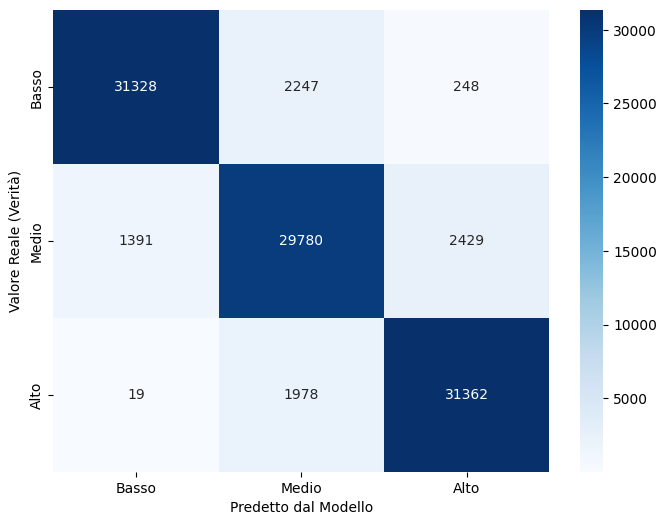

In [20]:
# Selezioniamo le features e creiamo X, le caratteristiche, e Y, la colonna output
features = ['temperature', 'humidity', 'hour', 'is_weekend', 'fascia_num', 'use_MA_3']
X = df[features]
y = df['target_carico']

# Creiamo l'albero
clf = DecisionTreeClassifier(max_depth=5) # Limitiamo la profondità per non farlo "imparare a memoria" overfitting
# Facciamo 10 run (Cross-Validation a 10 fold)
print(f"Avvio Cross-Validation (potrebbe volerci un momento dato il mezzo milione di righe)...")
scores = cross_val_score(clf, X, y, cv=10)

print(f"RISULTATI ALBERO DECISIONALE:")
print(f"Accuratezza Media su 10 run: {np.mean(scores):.2%}" )
print(f"Deviazione Standard: {np.std(scores):.2%}")
print(f"\n{'-' * 60}\n")

# Addestramento finale e Report dettagliato
# Dividiamo in Training set (80%) e Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train) #addestramento time
y_pred = clf.predict(X_test) #predizione sul test set

report_dict = classification_report(y_test, y_pred, target_names=['Basso', 'Medio', 'Alto'], output_dict=True) #dizionario
report_df = pd.DataFrame(report_dict).transpose().head(3) #trasformato in dataframe e prendiamo le classi che sono 3
report_df.columns = ['Precisione', 'Recall', 'F1-Score', 'Numero di righe (Esempi)']
tabella_percentuale = report_df.style.format({
    'Precisione': '{:.2%}',
    'Recall': '{:.2%}',
    'F1-Score': '{:.2%}',
    'Numero di righe (Esempi)': '{:.0f}'
})
print("PRESTAZIONI DEL MODELLO SUL TEST SET:")
display(tabella_percentuale)
print(f"\nAccuratezza Totale del Modello: {report_dict['accuracy']:.2%}")
print(f"\n{'-' * 60}\n")

# Tabella che incrocia la fascia prezzo con la categoria del carico
distribuzione = pd.crosstab(df['fascia_oraria'], df['target_carico'], normalize='index')
distribuzione.columns = ['Carico Basso', 'Carico Medio', 'Carico Alto']
distribuzione.index.name = 'Fascia Energetica'
distribuzione_perc = distribuzione.style.format('{:.2%}')
print("DISTRIBUZIONE DEI CONSUMI PER FASCIA ORARIA:")
display(distribuzione_perc)

#Matrice di confusione
print(f"\n{'-' * 60}\n")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Basso', 'Medio', 'Alto'], yticklabels=['Basso', 'Medio', 'Alto'], cmap='Blues')
plt.xlabel('Predetto dal Modello')
plt.ylabel('Valore Reale (Verità)')
plt.show()

**Parte 3**: Rete Neurale

*   Dai risultati emersi, non solo la rete neurale, che ha impiegato 27 minuti per addestrarsi, ha un'accuratezza minore rispetto all'albero decisionale, fra l'altro la fascia 2, quindi quella più problematica, ha una precisione più bassa.
*   Fare una cross-validation a 10 fold, come nell'albero decisionale, impiegherebbe 4 ore e mezza, considerando come per una ci abbia messo 27 minuti e lo dovrebbe fare per 10 volte. Quindi per la cross validation, visto che non si può fare per tutto il dataset, prendiamo 50 mila righe su cui fare i 10 fold.
* Nel primo tentativo, la rete neurale è di due strati, il primo contiene 100 neuroni e il secondo 50 neuroni, utilizzando la tecnica a imbuto. Proviamo con una rete neurale a tre stati, con il primo di 128 neuroni, la seconda di 64 neuroni e la terza di 32 neuroni e abbasso a un massimo di 300 iterate a 200.
* Una volta aumentata la rete neurale, l'esecuzione è durata per 1h e 06 min, arrivando ad una accuratezza del 91.58%, diminuita. La cross-validation invece non è terminata, quindi riprendo il MLP con meno neuroni e la cross-validation con 10 fold su 100.000 righe.
* Aggiunta la clausula early stop per finire l'addestramento se non si vede un miglioramento nelle scelte effettuate dalla rete, l'accuratezza è scesa al 91.59% mentre dal cross validation emerge che:
MLP Accuratezza Media: 91.24%
MLP Deviazione Standard: 0.0026, nettamnete migliore dell'albero, quindi è molto più stabile
Però il risultato è stato ricevuto in 5 minuti.
* Si decide di mantenere la rete con due layer ma diminuendo i neuroni a 64 e 32. I risultati emersi indicano una netta discesa dell'accuratezza ma anche della deviazione, l'unica cosa migliore che aveva, quindi effettivamente sono troppi pochi neuroni.

1. <b>Layer 2 </b>: 100 e 50 con early stop<br>
CONFRONTO FINALE:<br>
MLP Accuratezza Media: 91.24%<br>
MLP Deviazione Standard: 00.26%<br>
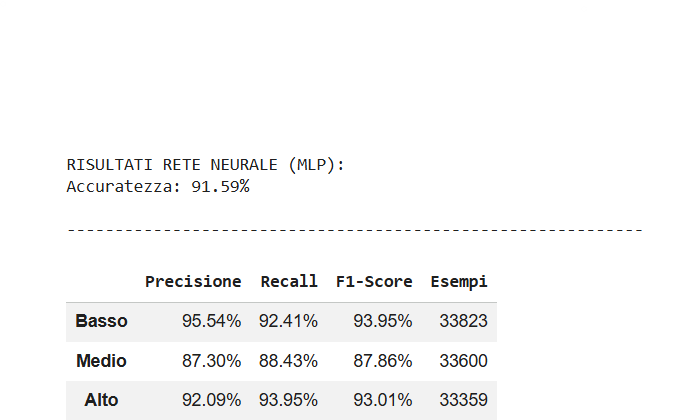 <br>

2. <b> Layer 2</b> : 100 e 50 <br>
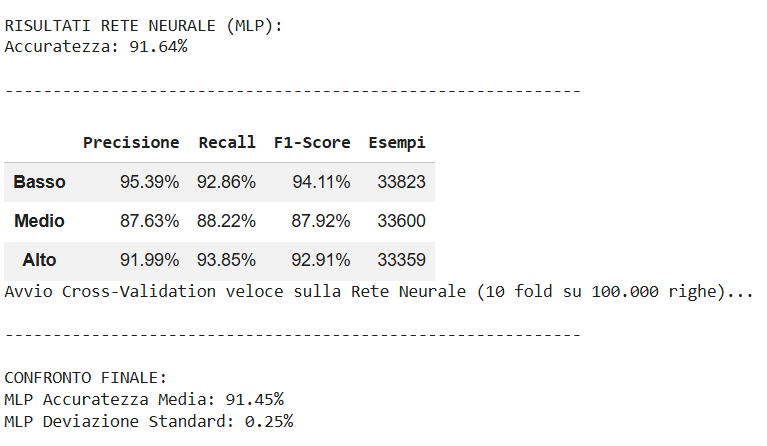
3. Layer 2 : 64 e 32 <br>
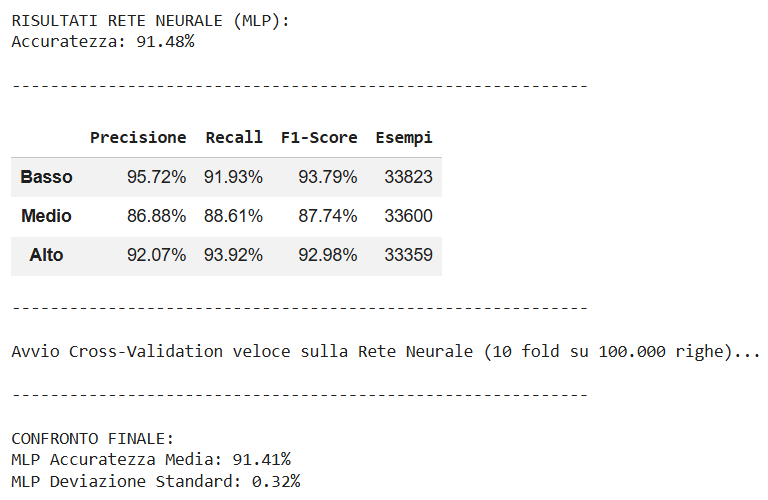

In [21]:
# Selezioniamo le features e creiamo X, le caratteristiche, e Y, la colonna output
features = ['temperature', 'humidity', 'hour', 'is_weekend', 'fascia_num', 'use_MA_3']
X = df[features]
y = df['target_carico']

# Dividiamo in Training set (80%) e Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzazione dei dati
# La Rete Neurale ha bisogno che i dati siano tutti sulla stessa scala (es. tra -1 e 1 o 0 e 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creazione della Rete Neurale
# Creiamo una rete con 2 strati nascosti: il primo da 100 neuroni, il secondo da 50
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42) #, verbose=True, early_stopping=True) # aggiungere fra i parametri
                                                                                               # verbose=True ci fa vedere la rete mentre "impara", con loss intende
                                                                                               # quanto sta effettivamente imparando e si deve abbassare sempre di più
                                                                                               # se per 10 iterazioni rimane pressoché simile, si ferma l'addestramento
                                                                                               # early_stopping= True, invece che dopo 10 loss uguali smesse, dopo poche
# mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=200, random_state=42)
# Addestramento
print("Inizio addestramento della Rete Neurale (MLP)...")
mlp.fit(X_train_scaled, y_train)

# Predizione e Risultati
y_pred_mlp = mlp.predict(X_test_scaled)
print(f"\n{'-' * 60}\n")
print("RISULTATI RETE NEURALE (MLP):")
print(f"Accuratezza: {accuracy_score(y_test, y_pred_mlp):.2%}")
print(f"\n{'-' * 60}\n")

report_mlp = classification_report(y_test, y_pred_mlp, target_names=['Basso', 'Medio', 'Alto'], output_dict=True)
report_mlp_df = pd.DataFrame(report_mlp).transpose().head(3)
report_mlp_df.columns = ['Precisione', 'Recall', 'F1-Score', 'Esempi']
report_mlp_df['Esempi'] = report_mlp_df['Esempi'].astype(int)
display(report_mlp_df.style.format({'Precisione': '{:.2%}', 'Recall': '{:.2%}', 'F1-Score': '{:.2%}', 'Esempi': '{:d}'}))
print(f"\n{'-' * 60}\n")

# Cross-Validation SOLO su un campione di 100 mila righe casuali (il 20% del dataset) e non su tutto, altrimenti ci mettiamo ore
df_sample = df.sample(n=100000, random_state=42)
X_sample = scaler.fit_transform(df_sample[features])
y_sample = df_sample['target_carico']

'''print("Avvio Cross-Validation veloce sulla Rete Neurale (10 fold su 100.000 righe)...")
cv_scores_mlp = cross_val_score(mlp, X_sample, y_sample, cv=10)

print(f"\n{'-' * 60}\n")
print(f"CONFRONTO FINALE:")
print(f"MLP Accuratezza Media: {np.mean(cv_scores_mlp):.2%}")
print(f"MLP Deviazione Standard: {np.std(cv_scores_mlp):.2%}")
print(f"\n{'-' * 60}\n")'''

Inizio addestramento della Rete Neurale (MLP)...

------------------------------------------------------------

RISULTATI RETE NEURALE (MLP):
Accuratezza: 91.64%

------------------------------------------------------------



,Precisione,Recall,F1-Score,Esempi
Basso,95.39%,92.86%,94.11%,33823
Medio,87.63%,88.22%,87.92%,33600
Alto,91.99%,93.85%,92.91%,33359



------------------------------------------------------------



'print("Avvio Cross-Validation veloce sulla Rete Neurale (10 fold su 100.000 righe)...")\ncv_scores_mlp = cross_val_score(mlp, X_sample, y_sample, cv=10)\n\nprint(f"\n{\'-\' * 60}\n")\nprint(f"CONFRONTO FINALE:")\nprint(f"MLP Accuratezza Media: {np.mean(cv_scores_mlp):.2%}")\nprint(f"MLP Deviazione Standard: {np.std(cv_scores_mlp):.2%}")\nprint(f"\n{\'-\' * 60}\n")'

**Parte 4** : Rete bayesiana

Si è osservato che le variabili ambientali (meteo e temperatura) da sole non sono sufficienti a determinare univocamente il carico energetico, portando a una distribuzione di probabilità quasi uniforme (circa 33% per ogni classe). Il modello acquisisce invece un'elevata confidenza predittiva solo quando viene integrato il contesto del trend di consumo recente, dimostrando che il comportamento dell'utente prevale sulle condizioni atmosferiche.<br> Purtroppo per quanto si sarebbe voluto aggiungere la presenza umana come cosa principale dei consumi, si è scelto di non includerla come variabile stimata per evitare di introdurre bias deterministici nel modello. Una stima della presenza basata su regole fisse renderebbe il sistema rigido; pertanto, si è preferito lasciare che la rete apprendesse le correlazioni dirette tra variabili ambientali e carico energetico, mantenendo l'integrità statistica dei dati osservati. Quindi si userà questa rete bayesiana per prevedere il carico e di conseguenza, in base alla KB, scegliere cosa spegnere, ritardare o meno.

In [22]:
def visualizza_risultati(q):
    # Definiamo la mappa dei nomi (Assicurati che l'ordine 0,1,2 sia quello del tuo dataset)
    mapping = {0: 'Basso', 1: 'Medio', 2: 'Alto'}

    # Estraiamo i valori
    valori = q.values

    print(f"{'Stato Carico':<15} | {'Probabilità':<10}")
    print("-" * 30)

    for i, prob in enumerate(valori):
        nome_classe = mapping.get(i, f"Classe {i}")
        print(f"{nome_classe:<15} | {prob:.2%}")

    print("\n")

In [23]:
# Creiamo una copia del dataset per la rete bayesiana
df_bayes = df.copy()

#Le reti bayesiane lavorano meglio con etichette, pittosto che con numeri decimali, quindi bisogna discretizzare tutti quei valori così.
#Per il carico in basso, alto, medio è già fatto
#Temperatura in 3 livelli, l'umidità in tre livelli, media degli ultimi consumi, l'orario e se sta piovendo o meno
df_bayes['temp_cat'] = pd.qcut(df['temperature'], q=3, labels=['Freddo', 'Mite', 'Caldo'])
df_bayes['umid_cat'] = pd.qcut(df['humidity'], q=3, labels=['Secco', 'Normale', 'Umido'])
df_bayes['media_mobile_cat'] = pd.qcut(df['use_MA_3'], q=3, labels=['Trend_Basso', 'Trend_Medio', 'Trend_Alto'])
df_bayes['hour_cat'] = pd.cut(df_bayes['hour'], bins=[0, 6, 12, 18, 24], labels=['Notte', 'Mattina', 'Pomeriggio', 'Sera'], include_lowest=True)
df_bayes['pioggia_cat'] = pd.cut(df['precipProbability'], bins=[-0.1, 0.1, 0.5, 1.1], labels=['No_Pioggia', 'Prob_Bassa', 'Prob_Alta'])

#Colonne che servono, prendiamo il dataframe bayes e lo riduciamo solo alle colonne che ci servono e non a tutte
colonne_df_bayes = ['pioggia_cat', 'fascia_oraria', 'temp_cat', 'umid_cat', 'media_mobile_cat', 'hour_cat', 'target_carico']
df_bayes = df_bayes[colonne_df_bayes].copy()

# Definiamo la struttura: (Sorgente(causa), Destinazione(effetto))
model = DiscreteBayesianNetwork([
    ('hour_cat', 'target_carico'),
    ('pioggia_cat', 'target_carico'),
    ('umid_cat', 'target_carico'),
    ('fascia_oraria', 'target_carico'),
    ('temp_cat', 'target_carico'),
    ('media_mobile_cat', 'target_carico')
])

print("Allenamento in corso...")
model.fit(df_bayes, estimator=MaximumLikelihoodEstimator)

inference = VariableElimination(model)

print("Qual è la probabilità del carico se è notte e la fascia energetica sia la 1? - SITUAZIONE IMPOSSIBILE, silenzio della macchina")
q_notte = inference.query(variables=['target_carico'],
                          evidence={'hour_cat': 'Notte', 'fascia_oraria': 'F1'})
visualizza_risultati(q_notte)

print("Qual è la probabilità del carico se è pomeriggio, la fascia energetica sia la 1 e la media dei consumi sia basso?")
q_pomeriggio = inference.query(variables=['target_carico'],
                               evidence={'hour_cat': 'Pomeriggio', 'fascia_oraria': 'F1', 'media_mobile_cat': 'Trend_Basso'})
visualizza_risultati(q_pomeriggio)

print("Qual è la probabilità del carico se fa freddo e probabilmente piove, è mattina e normalmente si ha una media dei consumi alta?")
q_notte_f3 = inference.query(variables=['target_carico'],
                             evidence={'pioggia_cat': 'Prob_Alta', 'temp_cat':'Freddo', 'hour_cat':'Mattina', 'media_mobile_cat': 'Trend_Alto'})
visualizza_risultati(q_notte_f3)

print("Qual è la probabilità del carico se è mattina nella fascia 1 e la media dei consumi è alto?")
q_reale = inference.query(variables=['target_carico'],
                          evidence={'hour_cat':'Mattina', 'fascia_oraria': 'F1', 'media_mobile_cat': 'Trend_Alto'})
visualizza_risultati(q_reale)

nodi_input = [nodo for nodo in model.nodes() if nodo != 'target_carico']

print("Calcolo delle predizioni in corso...")
X_test = df_bayes[nodi_input]
predictions = model.predict(X_test)

y_true = df_bayes['target_carico'].values
y_pred = predictions['target_carico'].values

acc_bayes = accuracy_score(y_true, y_pred)
print(f"Accuratezza Rete Bayesiana: {acc_bayes:.2%}")

Allenamento in corso...
Qual è la probabilità del carico se è notte e la fascia energetica sia la 1? - SITUAZIONE IMPOSSIBILE, silenzio della macchina
Stato Carico    | Probabilità
------------------------------
Basso           | 33.33%
Medio           | 33.33%
Alto            | 33.33%


Qual è la probabilità del carico se è pomeriggio, la fascia energetica sia la 1 e la media dei consumi sia basso?
Stato Carico    | Probabilità
------------------------------
Basso           | 90.30%
Medio           | 8.26%
Alto            | 1.44%


Qual è la probabilità del carico se fa freddo e probabilmente piove, è mattina e normalmente si ha una media dei consumi alta?
Stato Carico    | Probabilità
------------------------------
Basso           | 24.43%
Medio           | 26.16%
Alto            | 49.41%


Qual è la probabilità del carico se è mattina nella fascia 1 e la media dei consumi è alto?
Stato Carico    | Probabilità
------------------------------
Basso           | 2.16%
Medio           | 8

  0%|          | 0/518 [00:00<?, ?it/s]

Accuratezza Rete Bayesiana: 91.02%


**Parte 4** : Knowledge Base (Prolog)

In [24]:
from pyswip import Prolog
prolog = Prolog()

with open("kb_smarthome.pl", "w") as f:
    f.write("""
    % Definizione della tipologia e della priorità:
    % Tipologia: critico (non si spegne), sacrificabile (si può spegnere)
    tipo(frigo, critico).
    tipo(forno1, sacrificabile).
    tipo(forno2, sacrificabile).
    tipo(microonde, sacrificabile).
    tipo(lavastoviglie, sacrificabile).
    tipo(fornello, sacrificabile).

    % Priorità di distacco (1 = spegnere per primo, 4 = spegnere per ultimo)
    priorita_distacco(lavastoviglie, 1).
    priorita_distacco(fornello, 1).
    priorita_distacco(microonde, 2).
    priorita_distacco(forno2, 3).
    priorita_distacco(forno1, 4).

    % Regole:

    % --- REGOLE SPECIFICHE PER FASCIA F3 (Solo Sicurezza) ---
    % Se siamo in F3 consiglio per non fare saltare la corrente
    consiglio(Appliance, "SICUREZZA TECNICA: Anche se sei in fascia economica (F3), il carico totale è troppo alto e potrebbe verificarsi un blackout. Riduci l'uso di:") :-
        previsione_carico(alto),
        fascia_oraria(f3),
        stato(Appliance, acceso),
        tipo(Appliance, sacrificabile).

    % In questo caso, potresti volere un messaggio che rassicura l'utente
    consiglio(f3_ottimale, "OTTIMIZZAZIONE: Carico medio in fascia F3. Stai gestendo bene i tuoi consumi!") :-
        previsione_carico(medio),
        fascia_oraria(f3).

    % Se il fornello è acceso e il carico è alto, liberiamo spazio spegnendo i sacrificabili
    consiglio(Appliance, "PRIORITÀ CUCINA: Stai usando i fornelli. Per evitare distacchi, spegni:") :-
        previsione_carico(alto),
        stato(kitchen_stove, acceso),
        tipo(Appliance, sacrificabile),
        stato(Appliance, acceso).

    % Se è alta la produzione di energia solare, si può sfruttare
    consiglio(solare, "OTTIMIZZAZIONE: La produzione di energia solare è alta al momento! Per sfruttarla è possibile accendere elettrodomestici come la lavastoviglie") :-
        produzione_solare(alta),
        previsione_carico(basso).

    % Avviso per informare che non verrà spento il frigo ma che sta contribuendo
    consiglio(frigo, "INFO: Il frigo è in funzione e contribuisce al carico, ma non verrà disattivato.") :-
        previsione_carico(alto),
        stato(frigo, acceso).

    % Se forno e microonde sono accesi con carico alto, rischio immediato di blackout
    consiglio(sovraccarico, "PERICOLO BLACKOUT: Forno e Microonde accesi simultaneamente con carico ALTO. Spegni subito il Microonde!") :-
        previsione_carico(alto),
        stato(microwave, acceso),
        (stato(forno1, acceso) ; stato(forno2, acceso)).

    % Se la probabilità storica di carico alto è > 30% e il carico attuale è MEDIO, suggeriamo cautela prima che la situazione peggiori.
    consiglio(prudenza, "ATTENZIONE: Storicamente in questa fascia il rischio di picchi è alto. Evita di accendere nuovi carichi ora!") :-
        pericolo_statistico_fascia(P),
        P > 0.30,
        previsione_carico(medio).

    % Se il rischio storico è alto o se la previsione è ALTA ma non abbiamo carichi pesanti accesi da suggerire di spegnere.
    consiglio(prudenza, "ATTENZIONE: Previsione di carico elevato. Anche se i grandi elettrodomestici sono spenti, evita di accenderne di nuovi!") :-
        (previsione_carico(alto) ; (previsione_carico(medio), pericolo_statistico_fascia(P), P > 0.30)),
        \+ (stato(Appliance, acceso), tipo(Appliance, sacrificabile)).

    % Si spegne l'elettrodomestico sacrificabile ACCESO con la priorità più alta nella fascia F1
    consiglio(Appliance, "ECONOMIA: Fascia costosa e carico alto. Si consiglia di sospendere:") :-
        previsione_carico(alto),
        fascia_oraria(f1),
        stato(Appliance, acceso),
        tipo(Appliance, sacrificabile),
        priorita_distacco(Appliance, P),
        P =< 2. % Lavastoviglie e Microwave

    consiglio(Appliance, "CARICO CRITICO: Previsione alta. Se possibile, riduci l'uso di:") :-
        previsione_carico(alto),
        (fascia_oraria(f1) ; fascia_oraria(f2)),
        stato(Appliance, acceso),
        tipo(Appliance, sacrificabile),
        priorita_distacco(Appliance, P),
        P >= 3. % I forni
    """)

prolog.consult("kb_smarthome.pl")

<>:69: SyntaxWarning: invalid escape sequence '\+'
<>:69: SyntaxWarning: invalid escape sequence '\+'
/tmp/ipython-input-3217994637.py:69: SyntaxWarning: invalid escape sequence '\+'
  \+ (stato(Appliance, acceso), tipo(Appliance, sacrificabile)).


In [25]:
def aggiorna_prolog_senza_errori(riga):
    prolog.retractall("fascia(_)")
    prolog.retractall("stato(_, _)")
    prolog.retractall("previsione_carico(_)")

    f_raw = str(riga['fascia_oraria'].values[0]).lower().strip()
    prolog.assertz(f"fascia({f_raw})")

    traduzione_nomi = {
        "dishwasher": "lavastoviglie",
        "furnace1": "forno1",
        "furnace2": "forno2",
        "microwave": "microonde",
        "fridge": "frigo"
    }

    for col in riga.columns:
        if "[kW]" in col and col != 'use [kW]':
            valore = riga[col].values[0]
            nome_originale = col.replace(" [kW]", "").replace(" ", "").lower()
            nome_logico = traduzione_nomi.get(nome_originale, nome_originale)
            stato = "acceso" if valore > 0.1 else "spento"
            prolog.assertz(f"stato({nome_logico}, {stato})")

In [26]:
def ottieni_consigli_smart(modello_scelto, dati_per_modello, riga_sensori, nome_modello):
    mapping = {0: "basso", 1: "medio", 2: "alto"}

    try:
        if nome_modello == "Rete Bayesiana":
            dati_input = dati_per_modello.drop(columns=['target_carico'], errors='ignore')
            prob_df = modello_scelto.predict_probability(dati_input)
            id_pred_raw = prob_df.idxmax(axis=1).values[0]
            id_pred = id_pred_raw.split('_')[-1] if '_' in str(id_pred_raw) else id_pred_raw
            label_pred = mapping[int(id_pred)]
            print(f"Per il modello {nome_modello}, la probabilità che il carico sia {label_pred.upper()} è del {prob_df.max(axis=1).values[0]*100:.2f}%")
        elif nome_modello == "Albero Decisionale":
            cols = modello_scelto.feature_names_in_
            pred_val = modello_scelto.predict(dati_per_modello[cols])[0]
            label_pred = mapping[int(pred_val)]
            print(f"Il modello {nome_modello} predice che il carico sia {label_pred.upper()}")
        else:
            cols = X_train.columns
            pred_val = modello_scelto.predict(dati_per_modello[cols].values)[0]
            label_pred = mapping[int(pred_val)]
            print(f"Il modello {nome_modello} predice che il carico sia {label_pred.upper()}")
    except Exception as e:
        print(f"Errore {nome_modello}: {e}")
        return

    aggiorna_prolog_senza_errori(riga_sensori)

    #Controllo riguardo la storicità delle fasce
    fascia_corrente = riga_sensori['fascia_oraria'].values[0] # Es: 'F1'
    try:
        prob_alto_storica = distribuzione.loc[fascia_corrente, 'Carico Alto']
    except:
        prob_alto_storica = 0  # Valore di sicurezza se la fascia non esiste
    prolog.assertz(f"pericolo_statistico_fascia({prob_alto_storica})")

    # Controllo produzione solare
    valore_solare = riga_sensori['Solar [kW]'].values[0]
    if valore_solare > 0.4: #Produzione alta di energia solare se è maggiore di 0.4kW (nel dataset non è così alta, quindi ho dovuto abbassare)
        prolog.assertz("produzione_solare(alta)")
    else:
        prolog.assertz("produzione_solare(bassa)")

    prolog.assertz(f"previsione_carico({label_pred})")
    prolog.assertz(f"fascia_oraria({fascia_corrente.lower()})")

    #Consiglio dato dal modello
    res = list(prolog.query("consiglio(ID, Messaggio)"))

    if res:
        consigli = set()
        for r in res:
            msg = r['Messaggio'].decode('utf-8') if isinstance(r['Messaggio'], bytes) else r['Messaggio']
            identificatore = r['ID'].decode('utf-8') if isinstance(r['ID'], bytes) else r['ID']
            if identificatore != 'frigo' and identificatore != 'solare' and identificatore != 'sovraccarico' and identificatore != 'f3_ottimale' and identificatore != 'prudenza':
              consigli.add(f"  -> {msg} {identificatore.upper()}")
            else:
              consigli.add(f"  -> {msg}")

        for c in consigli:
            print(c)
    else:
        print("  -> Sistema in equilibrio. Nessun distacco necessario.")
    return label_pred

In [27]:
def test_comparativo_modelli(indice_scenario):
    riga_originale = df.iloc[[indice_scenario]]
    riga_bayes = df_bayes.iloc[[indice_scenario]]

    print(f"\nANALISI SCENARIO: {indice_scenario}")
    print(f"Carico Misurata: {df['use [kW]'].iloc[indice_scenario]:.4f} kW")

    # Lista modelli
    modelli = [
        ("Albero Decisionale", clf, riga_originale),
        ("Rete Neurale (MLP)", mlp, riga_originale),
        ("Rete Bayesiana", model, riga_bayes)
    ]

    risultati_individuali = []
    for nome, mod, dati in modelli:
        pred_label = ottieni_consigli_smart(mod, dati, riga_originale, nome)
        risultati_individuali.append(pred_label)
        print("-" * 40)

    # risposte: 0=Albero, 1=MLP, 2=Bayes
    decisione_integrata, motivo = predizione_integrata_voto(
        risultati_individuali[0],
        risultati_individuali[1],
        risultati_individuali[2]
    )

    print(f"\nEsito del voto: {motivo}")

    ragionamento_kb_finale(decisione_integrata, riga_originale)

In [49]:
def predizione_integrata_voto(pred_albero, pred_mlp, pred_bayes):
    mappa = {0: "basso", 1: "medio", 2: "alto"}
    p_a = mappa.get(pred_albero, pred_albero)
    p_m = mappa.get(pred_mlp, pred_mlp)
    p_b = mappa.get(pred_bayes, pred_bayes)

    if p_a == "alto" or p_b == "alto":
        return "alto", "Maggioranza"
    if p_a == "basso" or p_b == "basso":
        return "basso", "Fiducia nell'Albero/Bayes per carichi minimi"
    return "medio", "Carico gestibile"

In [29]:
def ragionamento_kb_finale(decisione_voto, riga_sensori):
    print("\n" + "="*60)
    print(f">>> ANALISI INTEGRATA KB FINALE (SISTEMA ESPERTO) <<<")
    print(f"Decisione tipologia del carico: {decisione_voto.upper()}")

    prolog.retractall("previsione_carico(_)")
    prolog.retractall("fascia_oraria(_)")
    prolog.retractall("produzione_solare(_)")
    prolog.retractall("pericolo_statistico_fascia(_)")
    prolog.assertz(f"previsione_carico({decisione_voto})")

    fascia_corrente = str(riga_sensori['fascia_oraria'].values[0]).lower().strip()
    prolog.assertz(f"fascia_oraria({fascia_corrente})")

    valore_solare = riga_sensori['Solar [kW]'].values[0]
    solare_status = "alta" if valore_solare > 0.4 else "bassa"
    prolog.assertz(f"produzione_solare({solare_status})")

    try:
        prob_alto_storica = distribuzione.loc[str(riga_sensori['fascia_oraria'].values[0]), 'Carico Alto']
    except:
        prob_alto_storica = 0
    prolog.assertz(f"pericolo_statistico_fascia({prob_alto_storica})")

    print(f"\nConsigli del sistema esperto: (Fascia {fascia_corrente.upper()}):")
    res_finale = list(prolog.query("consiglio(ID, Messaggio)"))

    if not res_finale:
        print("Nessuna anomalia rilevata. Il sistema opera in parametri nominali.")
    else:
        visti = set()
        for r in res_finale:
            msg = r['Messaggio'].decode('utf-8') if isinstance(r['Messaggio'], bytes) else r['Messaggio']
            identificatore = r['ID'].decode('utf-8') if isinstance(r['ID'], bytes) else r['ID']

            if identificatore in ['frigo', 'solare', 'sovraccarico', 'f3_ottimale', 'prudenza']:
                testo = msg
            else:
                testo = f"{msg} {identificatore.upper()}"
            if testo not in visti:
                print(testo)
                visti.add(testo)
    print("="*60 + "\n")

In [50]:
while True:
  try:
    n = int(input("Seleziona scenario (da 1 a 503.909) - 0 per uscire: "))
  except ValueError:
    print("Valore non valido. Riprova.")
    continue
  if n > 0 and n < 503910 :
    test_comparativo_modelli(n)
  elif n == 0:
    print("Grazie per aver usato il sistema intelligente EnergySafe!")
    break
  else:
    print("Indice scenario non esistente. Riprovarne un altro fra 1 e 509.909")

Seleziona scenario (da 1 a 503.909) - 0 per uscire: 1000

ANALISI SCENARIO: 1000
Carico Misurata: 1.5608 kW
Il modello Albero Decisionale predice che il carico sia ALTO
  -> SICUREZZA TECNICA: Anche se sei in fascia economica (F3), il carico totale è troppo alto e potrebbe verificarsi un blackout. Riduci l'uso di: FORNO1
  -> INFO: Il frigo è in funzione e contribuisce al carico, ma non verrà disattivato.
----------------------------------------
Il modello Rete Neurale (MLP) predice che il carico sia MEDIO
  -> OTTIMIZZAZIONE: Carico medio in fascia F3. Stai gestendo bene i tuoi consumi!
----------------------------------------
Per il modello Rete Bayesiana, la probabilità che il carico sia ALTO è del 93.48%
  -> SICUREZZA TECNICA: Anche se sei in fascia economica (F3), il carico totale è troppo alto e potrebbe verificarsi un blackout. Riduci l'uso di: FORNO1
  -> INFO: Il frigo è in funzione e contribuisce al carico, ma non verrà disattivato.
----------------------------------------

